# 📈 Predicting Next-Day Stock Closing Price

**Objective:** Use a stock's recent trading history (Open, High, Low, Volume) to predict its **next day's closing price** with regression models.

**Pipeline:**
1. Fetch historical OHLCV data with `yfinance`
2. Engineer a "next-day close" target
3. Split chronologically into train/test sets (no shuffling — this is time series!)
4. Train a **Linear Regression** model and a **Random Forest Regressor**
5. Evaluate with RMSE / MAE / R²
6. Plot actual vs. predicted closing prices

> ⚠️ **Disclaimer:** This notebook is for learning regression modeling and time-series workflows. Day-ahead stock prices are extremely hard to predict from price/volume alone — a model that tracks yesterday's close closely is not the same as a model that can find real, exploitable patterns. Nothing here is financial advice.

## 1. Setup
Install and import the libraries we need. In Google Colab, the `!pip install` line below is all you need — `yfinance` is not preinstalled.

In [1]:
# Run this once per Colab session
!pip install yfinance --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (14, 6)

## 2. Choose a stock and download data

Change `TICKER` to any symbol you like — e.g. `"AAPL"`, `"TSLA"`, `"MSFT"`, `"GOOGL"`.

In [3]:
TICKER = "AAPL"          # <-- change this to try another stock (e.g. "TSLA")
START_DATE = "2018-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# yfinance sometimes returns MultiIndex columns when given a single ticker as a list
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.shape)
df.tail()

[*********************100%***********************]  1 of 1 completed

(2132, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900
2026-06-25,275.149994,288.799988,273.750000,287.399994,107253700
2026-06-26,283.779999,285.950012,274.209991,275.000000,261693600


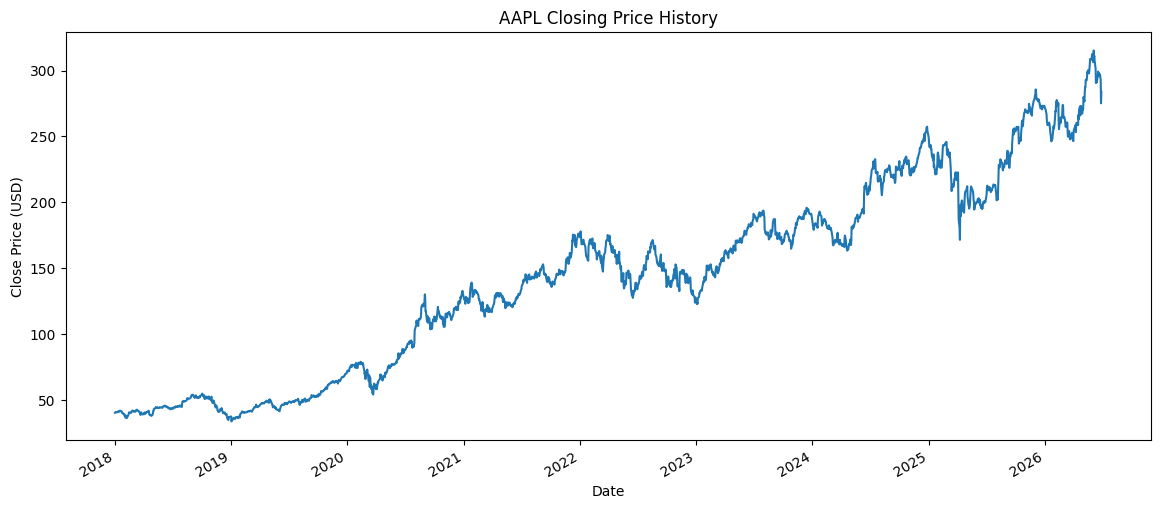

In [4]:
# Quick look at the raw closing price history
df["Close"].plot(title=f"{TICKER} Closing Price History")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.show()

## 3. Feature engineering

We use today's **Open, High, Low, Close, Volume** to predict **tomorrow's Close**.
That means the target column is the `Close` price *shifted back by one row* (`shift(-1)`).

In [5]:
data = df[["Open", "High", "Low", "Close", "Volume"]].copy()
data["Target"] = data["Close"].shift(-1)   # next day's close
data.dropna(inplace=True)                  # last row has no "next day" yet

data.tail()

Price,Open,High,Low,Close,Volume,Target
Date,,,,,,
2026-06-18,298.109985,300.570007,295.619995,298.010010,85962200,297.010010
2026-06-22,297.309998,302.420013,296.760010,297.010010,44879900,294.299988
2026-06-23,297.540009,301.640015,294.179993,294.299988,52010900,293.079987
2026-06-24,295.359985,299.700012,292.940002,293.079987,53081900,275.149994
2026-06-25,287.399994,288.799988,273.750000,275.149994,107253700,283.779999


## 4. Train / test split

Stock data is a **time series**, so we must NOT shuffle randomly — that would let the
model "see the future." Instead we take the first 80% of dates as training data and the
final 20% (most recent) as the test set.

In [6]:
FEATURES = ["Open", "High", "Low", "Close", "Volume"]

X = data[FEATURES]
y = data["Target"]

split_idx = int(len(data) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = data.index[split_idx:]

print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")

Train rows: 1704  |  Test rows: 427


## 5. Train the models

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

## 6. Evaluate

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>20s}  |  RMSE: {rmse:7.3f}   MAE: {mae:7.3f}   R²: {r2:6.4f}")
    return rmse, mae, r2

print(f"Results for {TICKER}\n" + "-" * 60)
evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")

# Naive baseline: "tomorrow's close = today's close" — a good sanity check.
# Beating this baseline is the real test of whether a model adds value.
naive_preds = X_test["Close"].values
print("-" * 60)
evaluate(y_test, naive_preds, "Naive (today=tomorrow)")

Results for AAPL
------------------------------------------------------------
   Linear Regression  |  RMSE:   4.233   MAE:   2.902   R²: 0.9794
       Random Forest  |  RMSE:  29.923   MAE:  21.519   R²: -0.0298
------------------------------------------------------------
Naive (today=tomorrow)  |  RMSE:   4.153   MAE:   2.846   R²: 0.9802


(np.float64(4.152508127271661), 2.8457184552588006, 0.9801676448720813)

## 7. Plot: Actual vs Predicted Closing Price

Note how closely all three lines (including the naive baseline) tend to track each other.
That's expected: tomorrow's close is usually close to today's close, so a model has to
work hard to beat that baseline rather than just learn to copy it.

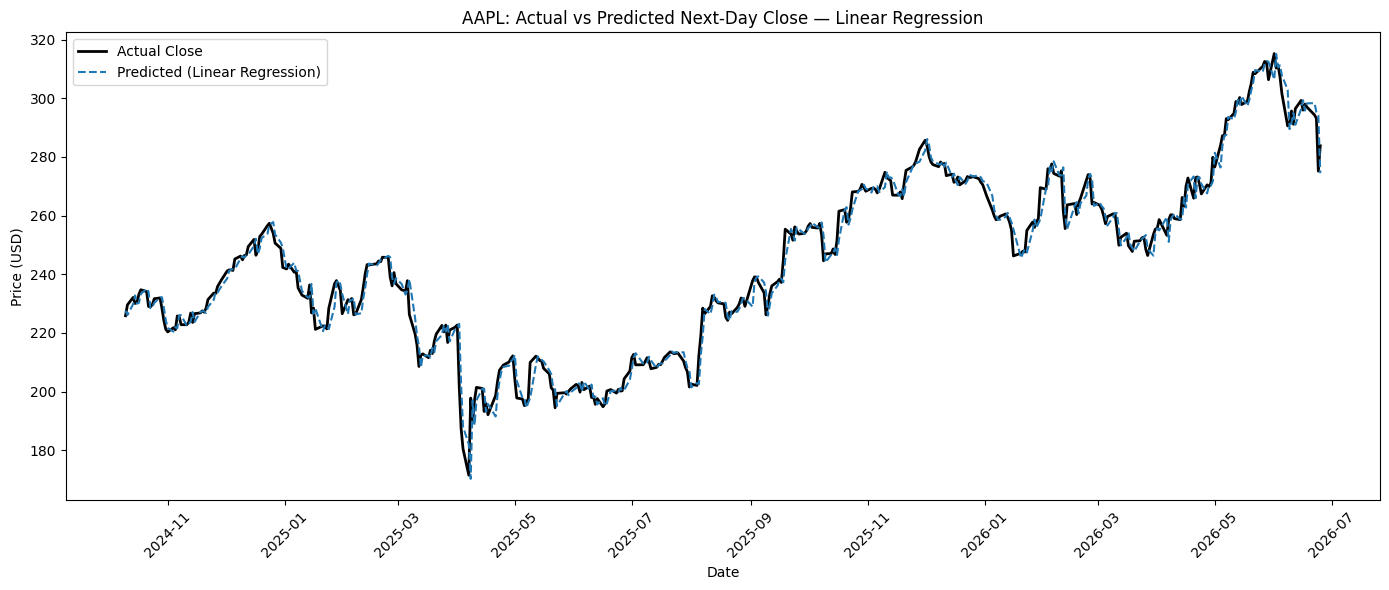

In [10]:
plt.figure()
plt.plot(test_dates, y_test.values, label="Actual Close", color="black", linewidth=2)
plt.plot(test_dates, lr_preds, label="Predicted (Linear Regression)", linestyle="--")
plt.title(f"{TICKER}: Actual vs Predicted Next-Day Close — Linear Regression")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

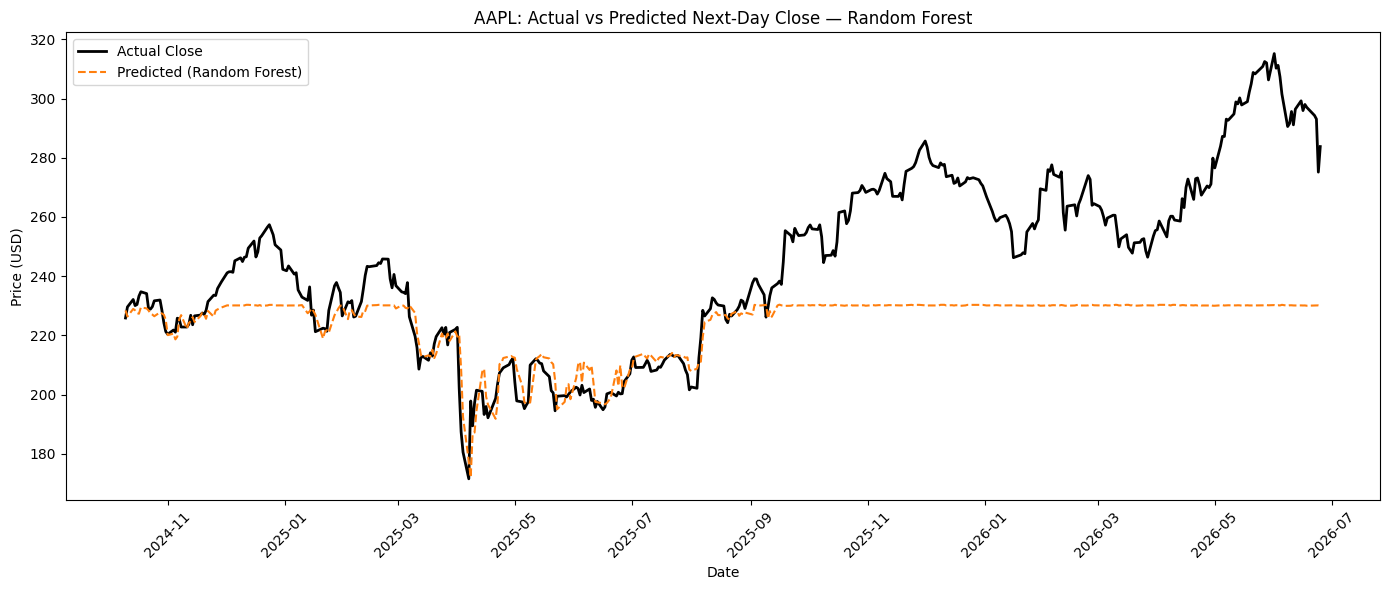

In [11]:
plt.figure()
plt.plot(test_dates, y_test.values, label="Actual Close", color="black", linewidth=2)
plt.plot(test_dates, rf_preds, label="Predicted (Random Forest)", linestyle="--", color="tab:orange")
plt.title(f"{TICKER}: Actual vs Predicted Next-Day Close — Random Forest")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

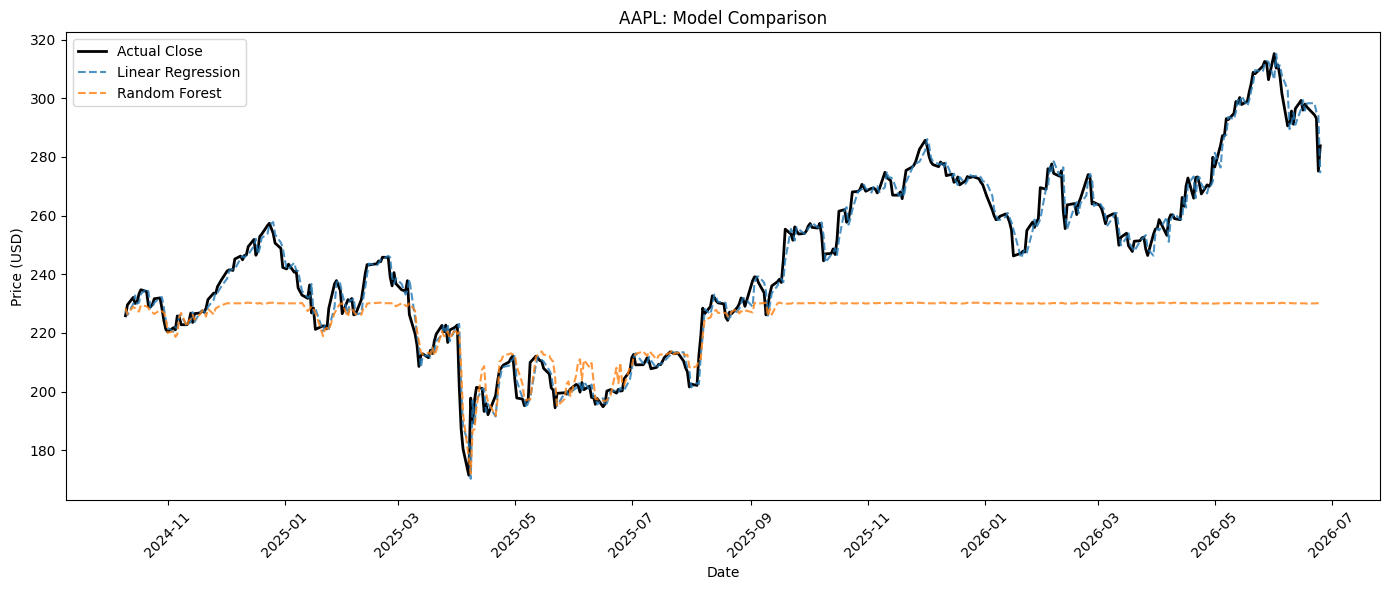

In [12]:
# Side-by-side comparison of both models against the actual price
plt.figure()
plt.plot(test_dates, y_test.values, label="Actual Close", color="black", linewidth=2)
plt.plot(test_dates, lr_preds, label="Linear Regression", linestyle="--", alpha=0.8)
plt.plot(test_dates, rf_preds, label="Random Forest", linestyle="--", alpha=0.8)
plt.title(f"{TICKER}: Model Comparison")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. (Bonus) Feature importance — what is the Random Forest actually using?

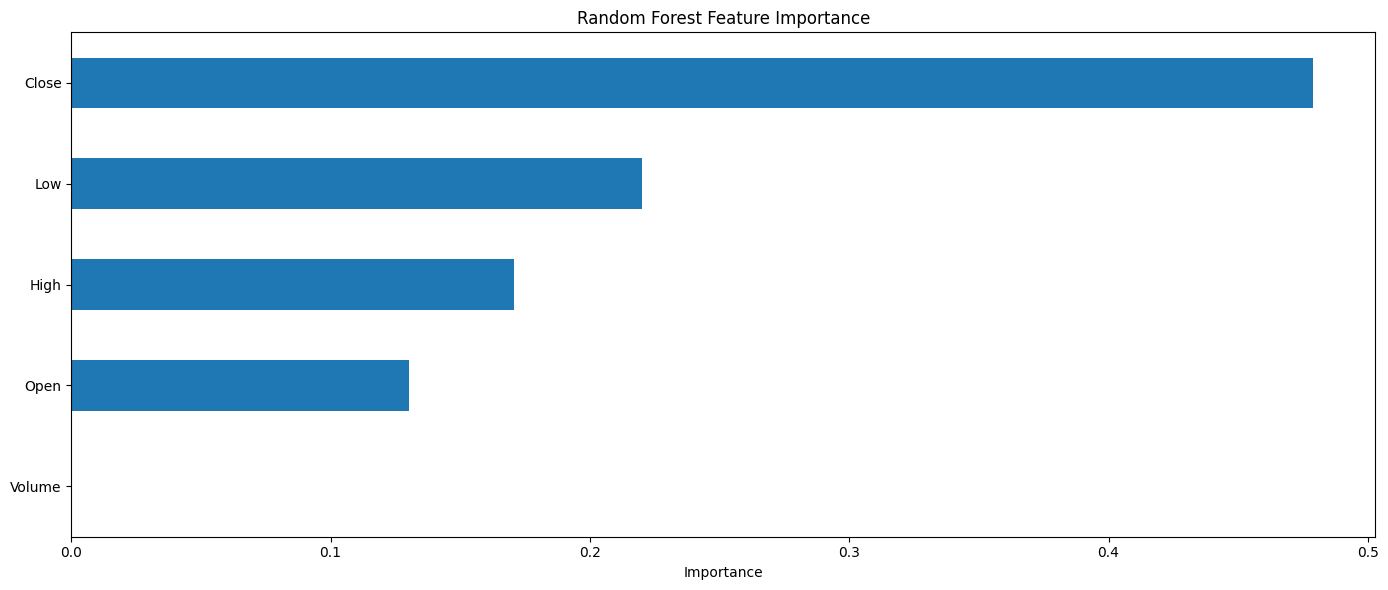

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", title="Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. (Bonus) Predict tomorrow's close from the most recent trading day

In [14]:
latest_row = X.iloc[[-1]]
lr_next = lr_model.predict(latest_row)[0]
rf_next = rf_model.predict(latest_row)[0]

last_date = X.index[-1].date()
print(f"Last available data point: {last_date}  (Close = {X.iloc[-1]['Close']:.2f})")
print(f"Linear Regression predicts next close: ${lr_next:.2f}")
print(f"Random Forest predicts next close:     ${rf_next:.2f}")

Last available data point: 2026-06-25  (Close = 275.15)
Linear Regression predicts next close: $274.44
Random Forest predicts next close:     $230.00


## Ideas to extend this notebook

- Add technical indicators as extra features (moving averages, RSI, MACD, daily % change)
- Try `XGBoost` / `LightGBM` or an LSTM for sequence modeling
- Use `TimeSeriesSplit` for more rigorous cross-validation instead of one train/test split
- Predict the *direction* (up/down) instead of the exact price — often more reliable
- Compare multiple tickers side by side